In [1]:
import os

if "GROQ_API_KEY" not in os.environ:
    raise EnvironmentError("GROQ_API_KEY environment variable is not set.")

In [7]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)
response = llm.invoke("What is the capital of France?").content
print(response)


The capital of France is Paris.


In [11]:
from pydantic import BaseModel,Field

class Graph_Schema(BaseModel):
    topic : str = Field(desciption="The name of the graph")
    post : str = Field(description="The post content")
    curated_post : str = Field(description="The Curated linkedin Post")

    

C:\Users\DELL\AppData\Local\Temp\ipykernel_14652\700025708.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'desciption'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  topic : str = Field(desciption="The name of the graph")


Create the Node function

In [ ]:
#create a create post node
def create_post(state:Graph_Schema) -> Graph_Schema:
    #convert instance to dict
    state = state.model_dump()

    topic = state["topic"]
    post = llm.invoke(f"Create a Linkedin Post about {topic}").content

    #Update the post in the state
    state["post"] = post

    return state


#create another curated post node
def curated_post_node(state:Graph_Schema) -> Graph_Schema:
    #convert instance to dict
    state = state.model_dump()
    post = state["post"]
    curated_post = llm.invoke(f"Curate the following Linkedin post to make it more engaging and concise: {post}").content

    #Update the curetd posr
    state["curated_post"] = curated_post

    return state


Create a state graph

In [21]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(Graph_Schema)

#add nodes to the graph
graph.add_node("create_post",create_post)

graph.add_node("curated_post_node",curated_post_node)

#add edges to the graph
graph.add_edge(START,"create_post")
graph.add_edge("create_post","curated_post_node")
graph.add_edge("curated_post_node",END)

Compile the Graph

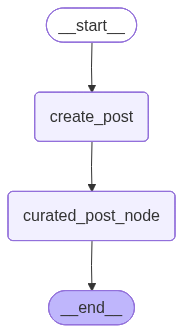

In [22]:
from IPython.display import Image,display

first_graph = graph.compile()
Image(first_graph.get_graph().draw_mermaid_png())


Run the Graph

In [23]:
first_graph.invoke({
    "topic":"Artificial Intelligence",
    "post":"",
    "curated_post":""
})

{'topic': 'Artificial Intelligence',
 'post': "**Unlocking the Future of Business: The Power of Artificial Intelligence**\n\nAs we continue to navigate the ever-changing landscape of the digital age, one thing is clear: Artificial Intelligence (AI) is revolutionizing the way we work, interact, and innovate.\n\nFrom improving customer experiences to driving business efficiency and growth, AI is no longer just a buzzword – it's a reality that's transforming industries and shaping the future of work.\n\n**The Benefits of AI:**\n\n1. **Enhanced Decision Making**: AI-powered analytics and insights help businesses make data-driven decisions, reducing the risk of human error and increasing productivity.\n2. **Personalized Customer Experience**: AI-driven chatbots and virtual assistants enable businesses to deliver tailored experiences, improving customer satisfaction and loyalty.\n3. **Streamlined Operations**: AI automation and process optimization help companies reduce costs, increase effic